<a href="https://colab.research.google.com/github/LucioFassarella/Ensino/blob/main/Estatistica_RegressaoLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear

<b>Regressão Linear</b> pelo <i>Método dos Mínimos Quadrados</i>, ou seja, o método básico para determinar a função que  melhor se ajusta a um conjunto de dados para duas variáveis correlacionadas.

Também implementamos métodos para o cálculo do <i>Coeficiente de Correlação de Pearson</i> e <i>Coeficiente de Deteminação</i>, que respectivamente medem a <i>coorrelação linear</i> entre duas variáveis e a <i>adequação do modelo linear</i> para a relação entre as variáveis.

<ul>
<li>
<b>Coeficiente de correlação $r$</b>:  mede a correlação linear entre dois conjuntos de dados.

*   $r$ varia entre $-1$ e $1$, sendo que $r \approx 0$ indica que as variáveis são independentes, $r=1 \approx 1$ indica que as variáveis são diretamente proporcionais, enquanto $r \approx -1$ indica que as variáveis são inversamente proporcionais:
$$
\begin{split}
r \in \left\lbrack -1, 1 \right\rbrack; & \\
r \approx 0 &\leadsto \text{variáveis independentes}\\
r \approx 1 &\leadsto \text{variáveis diretamente proporcionais}\\
r \approx 1 &\leadsto \text{variáveis inversamente proporcionais}
\end{split}
$$
</li>
<li>
<b>Coeficiente de determinação $R^2$</b>: medida de ajuste de um modelo estatístico linear generalizado (regressão linear)para um conjunto de valores observados de uma variável aleatória.

*   $R^2$ varia entre $0$ e $1$, sendo que $0$ indica completa inadequação do modelo linear, enquanto $1$ indica perfeita adequação do modelo linear:
$$
\begin{split}
R^2 \in \left\lbrack 0,1\right\rbrack; & \\
R^2 &\approx 0 \leadsto \text{modelo linear é inadequado}\\
R^2 &\approx 1 \leadsto \text{modelo linear é adequado}
\end{split}
$$
</li>
</ul>

In [3]:
def regressao_linear(x, y):
    '''
    Método para cálculo da regressão linear
    (i.e., coeficientes 'a' e 'b' do modelo linear y = ax + b)

    Entrada
    x: vetor de dados
    y: vetor de dados

    Saída
    a: coeficiente angular
    b: coeficiente linear

    Observação: os tamanhos dos vetores x e y devem ser iguais
    '''

    comprimento = len(x)

    if comprimento != len(y):
        print('ERRO! Os vetores x e y devem ter o mesmo comprimento')
        return

    media_x = sum(x)/comprimento
    media_y = sum(y)/comprimento

    numerador = 0
    for i in range(comprimento):
        numerador += (x[i]- media_x)*(y[i] - media_y)

    denominador = 0
    for i in range(comprimento):
        denominador += (x[i]- media_x)**2

    a = numerador/denominador

    b = media_y - a*media_x

    return a, b

def correlacao_pearson(x, y):
    '''
    Método para cálculo do coeficiente de correlação de Pearson

    Entrada
    x: vetor de dados
    y: vetor de dados

    Saída
    r: coeficiente de correlação de Pearson

    Observação: os tamanhos dos vetores x e y devem ser iguais
    '''

    comprimento = len(x)

    if comprimento != len(y):
        print('ERRO! Os vetores x e y devem ter o mesmo comprimento')
        return

    media_x = sum(x)/comprimento
    media_y = sum(y)/comprimento

    numerador = 0
    desvio_padrao_x = 0
    desvio_padrao_y = 0

    for i in range(comprimento):
        numerador += (x[i]-media_x)*(y[i]-media_y)

    for i in range(comprimento):
        desvio_padrao_x += (x[i]-media_x)**2
        desvio_padrao_y += (y[i]-media_y)**2

    denominador = (desvio_padrao_x*desvio_padrao_y)

    correlacao = numerador/denominador

    return correlacao

def determinacao(x, y):
    '''
    Método para cálculo do coeficiente de determinação

    Entrada
    x: vetor de dados
    y: vetor de dados

    Saída
    R2: coeficiente de determinação

    Observação: os tamanhos dos vetores x e y devem ser iguais
    '''

    comprimento = len(x)

    if comprimento != len(y):
        print('ERRO! Os vetores x e y devem ter o mesmo comprimento')
        return

    media_y = sum(y)/len(y)

    a, b = regressao_linear(x, y)

    # Desvio quadrático total total
    SQT = 0
    for i in range(comprimento):
        SQT += (y[i]- media_y)**2

    # Desvio quadrático total experimental
    SQE = 0
    for i in range(comprimento):
        SQE += ((a*x[i] + b) - media_y)**2

    R2 = SQE/SQT

    return R2

## Exemplo 1: **Curva de calibração espectrofotométrica**

Em um ensaio de doseamento por espectrofotometria UV-Vis, foram preparadas cinco soluções-padrão de
um fármaco em diferentes concentrações, medindo-se a absorbância de cada uma. Os dados obtidos
foram:

$$
\small
\begin{array}{|c|c|c|c|c|c|}
\hline
\text{Concentração $x$ (µg/mL)} & 2 & 4 & 6 & 8 & 10 \\
\hline
\text{Absorbância $y$} & 0,10 & 0,20 & 0,30 & 0,42 & 0,48 \\
\hline
\end{array}
$$


1.  Determine a equação da reta de calibração $\hat{y} = a + bx$ pelo método dos mínimos quadrados.
2.  Calcule o coeficiente de correlação $r$ e o coeficiente de determinação $R^2$. O ajuste linear é adequado?
3.  Uma amostra desconhecida apresentou absorbância de $0,35$. Estime a concentração do fármaco nessa amostra.


a = 0.048999999999999995
b = 0.006000000000000005


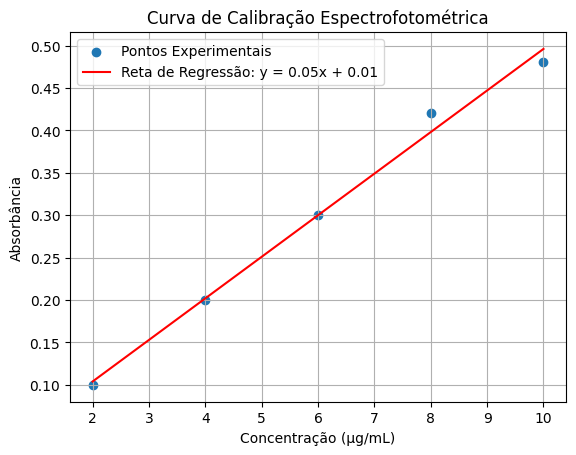

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
x = [2, 4, 6, 8, 10]
y = [0.1, 0.2, 0.3, 0.42, 0.48]

# Regressão linear (assuming regressao_linear is defined in a preceding cell)
a, b = regressao_linear(x, y)

print('a =', a)
print('b =', b)

# Gerando pontos para a reta de regressão
x_line = np.linspace(min(x), max(x), 100)
y_line = [a * val + b for val in x_line]

# Plotando os pontos experimentais
plt.scatter(x, y, label='Pontos Experimentais')

# Plotando a reta de regressão
plt.plot(x_line, y_line, color='red', label=f'Reta de Regressão: y = {a:.2f}x + {b:.2f}')

plt.xlabel('Concentração (µg/mL)')
plt.ylabel('Absorbância')
plt.title('Curva de Calibração Espectrofotométrica')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Cálculo do coeficiente de correlação r
r = correlacao_pearson(x, y)
print(f'Coeficiente de Correlação (r): {r:.4f}')

# Cálculo do coeficiente de determinação R^2
R2 = determinacao(x, y)
print(f'Coeficiente de Determinação (R^2): {R2:.4f}')

# Avaliação do ajuste linear
if R2 >= 0.95:
    mensagem = 'O modelo linear é adequado para a relação entre as variáveis.'
elif R2 >= 0.8:
    mensagem = 'O modelo linear apresenta uma boa adequação, mas pode haver espaço para melhorias ou outros fatores influenciando a relação.'
else:
    mensagem = 'O modelo linear é inadequado para a relação entre as variáveis.'

print(f'Avaliação do Ajuste Linear: {mensagem}')

Coeficiente de Correlação (r): 0.5062
Coeficiente de Determinação (R^2): 0.9921
Avaliação do Ajuste Linear: O modelo linear é adequado para a relação entre as variáveis.
